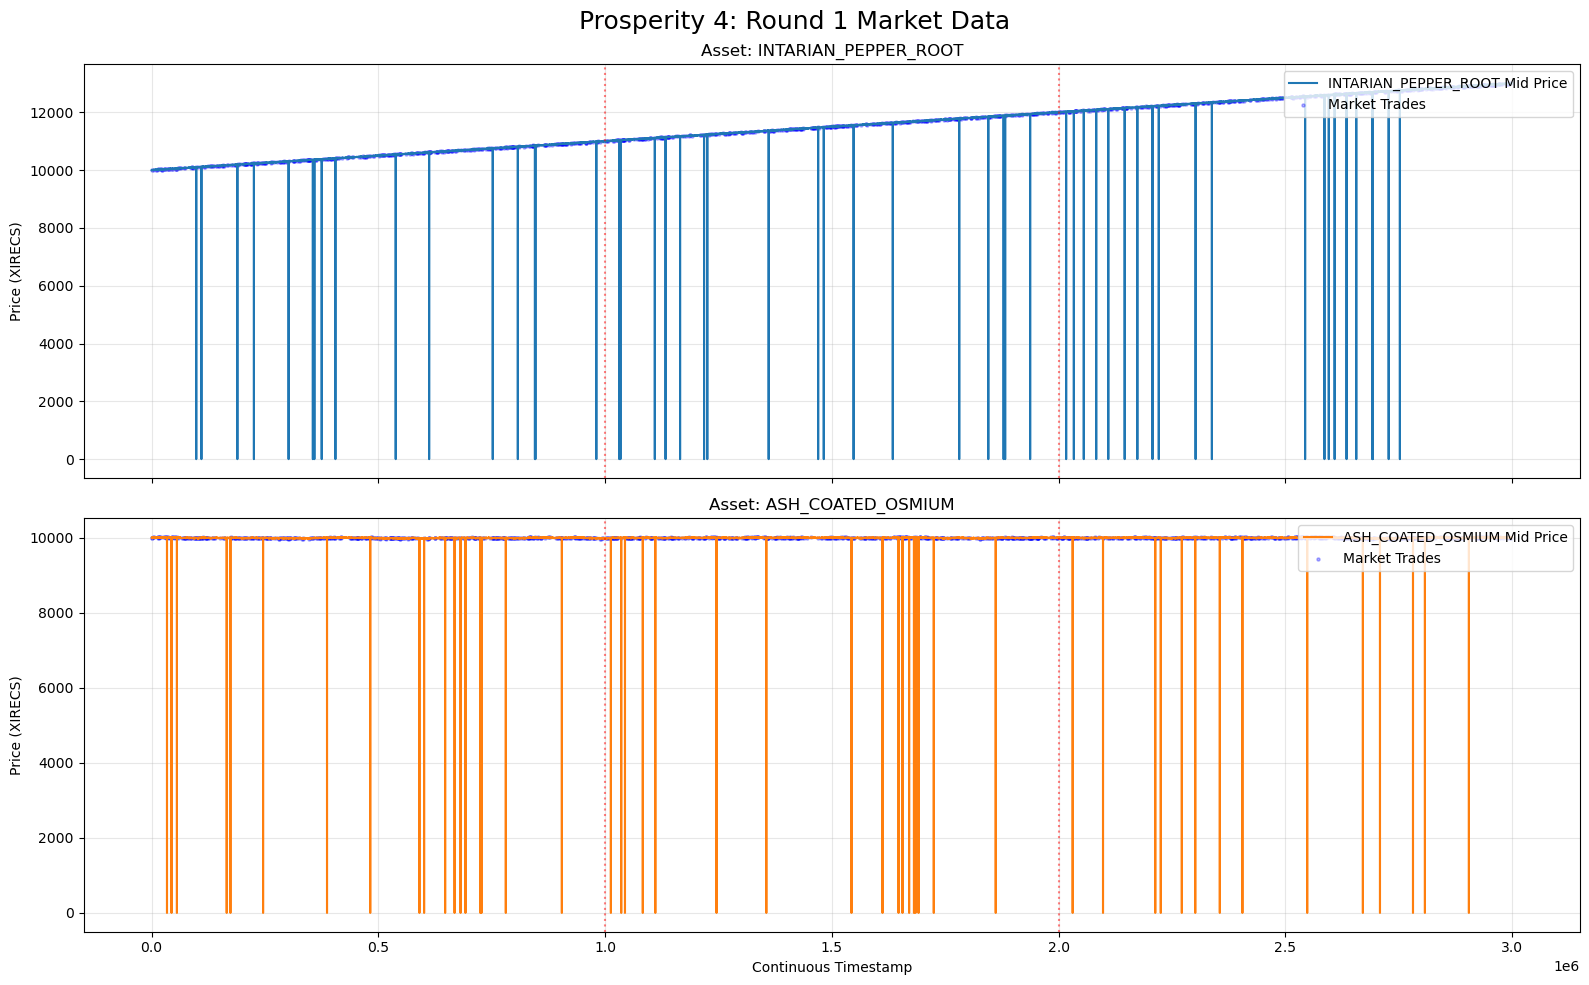

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define the path to your Round 1 data folder
data_folder = "/home/chesy/Projects/imc-prosperity-4-backtester/prosperity4bt/resources/round1/"

# 2. We will stitch these days together (Assuming Round 1 data uses days -2, -1, 0)
# Note: If the files are named day_1, day_2, day_3, change this list to [1, 2, 3]
days = [-2, -1, 0]
all_prices = []
all_trades = []

# 3. Load and offset the timestamps
for i, day in enumerate(days):
    price_file = f"{data_folder}/prices_round_1_day_{day}.csv"
    trade_file = f"{data_folder}/trades_round_1_day_{day}.csv"
    
    time_offset = i * 1000000 
    
    # Load Prices
    if os.path.exists(price_file):
        df_price = pd.read_csv(price_file, sep=";")
        df_price['timestamp'] += time_offset
        all_prices.append(df_price)
        
    # Load Trades
    if os.path.exists(trade_file):
        df_trade = pd.read_csv(trade_file, sep=";")
        df_trade['timestamp'] += time_offset
        all_trades.append(df_trade)

# Combine the lists into massive dataframes
if len(all_prices) == 0:
    print("Error: No price files found! Check your data_folder path and day numbers.")
else:
    df_prices_full = pd.concat(all_prices, ignore_index=True)
    df_trades_full = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()

    # --- DYNAMIC PLOTTING ---
    # Find all unique products in the Round 1 data automatically
    products = df_prices_full['product'].unique()
    num_products = len(products)

    # Create exactly as many subplots as there are products
    fig, axes = plt.subplots(num_products, 1, figsize=(16, 5 * num_products), sharex=True)
    fig.suptitle('Prosperity 4: Round 1 Market Data', fontsize=18)

    # If there's only one product (unlikely), make axes iterable
    if num_products == 1:
        axes = [axes]

    # Loop through each product and draw its plot
    for i, product in enumerate(products):
        ax = axes[i]
        prod_data = df_prices_full[df_prices_full['product'] == product]
        
        # Plot Mid Price
        ax.plot(prod_data['timestamp'], prod_data['mid_price'], label=f'{product} Mid Price', linewidth=1.5, color='C'+str(i))
        
        # Add a fair value line for Emeralds specifically
        if product == 'EMERALDS':
            ax.axhline(10000, color='black', linestyle='--', alpha=0.5, label='Fair Value (10k)')
        
        # Plot Market Trades if available
        if not df_trades_full.empty:
            trades = df_trades_full[df_trades_full['symbol'] == product]
            ax.scatter(trades['timestamp'], trades['price'], color='blue', s=5, alpha=0.3, label='Market Trades')

        # Formatting
        ax.set_title(f'Asset: {product}')
        ax.set_ylabel('Price (XIRECS)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        # Draw vertical lines to show where the days change
        for offset in [1000000, 2000000]:
            ax.axvline(offset, color='red', linestyle=':', alpha=0.5)

    plt.xlabel('Continuous Timestamp')
    plt.tight_layout()
    plt.show()